# Этап 1: Анализ датасета ITM-REC

Этот ноутбук содержит полный анализ датасета ITM-REC:
- Загрузка данных с Kaggle
- Базовый EDA (распределения, статистики)
- Корреляционный анализ
- Анализ влияния контекстных переменных
- Временные паттерны
- Визуализации всех результатов

In [1]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Импорт модулей проекта
import sys
sys.path.append('../')

from src.data.loaders import download_kaggle_dataset, load_all_data
from src.data.preprocessing import fill_missing_values, validate_data
from src.utils.visualization import plot_distributions, plot_correlations

# Настройка визуализаций
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

## 1. Загрузка данных с Kaggle

In [2]:
# Загрузка датасета с Kaggle
# Примечание: требуется настроенный Kaggle API (kaggle.json в ~/.kaggle/)
data_path = download_kaggle_dataset("irecsys/itmrec", "data/raw")

# Загрузка всех данных
data = load_all_data(data_path, load_group_ratings=False)
ratings = data['ratings']
users = data['users']
items = data['items']

Загрузка датасета irecsys/itmrec с Kaggle...
ЗАГРУЗКА ДАТАСЕТА ITM-REC
Загружено 5230 записей рейтингов
Загружено 476 пользователей
Загружено 70 предметов

Размеры загруженных таблиц:
- ratings: (5230, 9)
- users: (476, 4)
- items: (70, 4)


## 2. Базовая информация о данных

In [3]:
# Базовый осмотр рейтингов
print("="*50)
print("БАЗОВАЯ ИНФОРМАЦИЯ О ДАННЫХ")
print("="*50)

print("\n1. Первые 5 строк таблицы ratings:")
display(ratings.head())

print("\n2. Информация о типах данных и пропусках:")
ratings.info()

print("\n3. Базовая статистика числовых колонок:")
display(ratings.describe().round(2))

# Проверка уникальных значений
print("\n4. Уникальные значения в ключевых колонках:")
print(f"Уникальных пользователей: {ratings['UserID'].nunique()}")
print(f"Уникальных тем проектов: {ratings['Item'].nunique()}")
print(f"Семестры: {ratings['Semester'].unique()}")
print(f"Классы (специализации): {ratings['Class'].unique()}")
print(f"Периоды COVID: {ratings['Lockdown'].unique()}")

# Валидация данных
validate_data(ratings, users, items)

БАЗОВАЯ ИНФОРМАЦИЯ О ДАННЫХ

1. Первые 5 строк таблицы ratings:


,UserID,Item,Rating,App,Data,Ease,Class,Semester,Lockdown
0,1173,28,5,4,4.0,4,DA,Fall,PRE
1,1173,41,5,4,4.0,4,DA,Fall,PRE
2,1173,61,4,4,4.0,4,DA,Fall,PRE
3,1173,22,1,1,2.0,2,DA,Fall,PRE
4,1173,27,1,1,2.0,2,DA,Fall,PRE



2. Информация о типах данных и пропусках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5230 entries, 0 to 5229
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   UserID    5230 non-null   int64  
 1   Item      5230 non-null   int64  
 2   Rating    5230 non-null   int64  
 3   App       5230 non-null   int64  
 4   Data      5228 non-null   float64
 5   Ease      5230 non-null   int64  
 6   Class     5230 non-null   object 
 7   Semester  5230 non-null   object 
 8   Lockdown  5230 non-null   object 
dtypes: float64(1), int64(5), object(3)
memory usage: 367.9+ KB

3. Базовая статистика числовых колонок:


,UserID,Item,Rating,App,Data,Ease
count,5230.00,5230.00,5230.00,5230.00,5228.00,5230.00
mean,1248.54,36.58,3.37,3.42,3.39,3.18
std,141.91,18.51,1.44,1.29,1.22,1.13
min,1000.00,1.00,1.00,1.00,1.00,1.00
25%,1128.00,23.00,2.00,2.00,3.00,2.00
50%,1251.50,34.00,4.00,4.00,4.00,3.00
75%,1373.00,51.00,5.00,4.00,4.00,4.00
max,1492.00,70.00,5.00,5.00,5.00,5.00



4. Уникальные значения в ключевых колонках:
Уникальных пользователей: 454
Уникальных тем проектов: 70
Семестры: ['Fall' 'Spring']
Классы (специализации): ['DA' 'DB' 'DM']
Периоды COVID: ['PRE' 'DUR' 'POS']
Валидация данных пройдена успешно


True

## 3. Предобработка данных

In [4]:
# Заполнение пропусков
ratings_processed = fill_missing_values(ratings, strategy='median')

print("Пропуски после обработки:")
print(ratings_processed.isna().sum())

Заполнено 0 пропусков в колонке Data значением 4.00
Пропуски после обработки:
UserID      0
Item        0
Rating      0
App         0
Data        0
Ease        0
Class       0
Semester    0
Lockdown    0
dtype: int64


## 4. Анализ распределений рейтингов

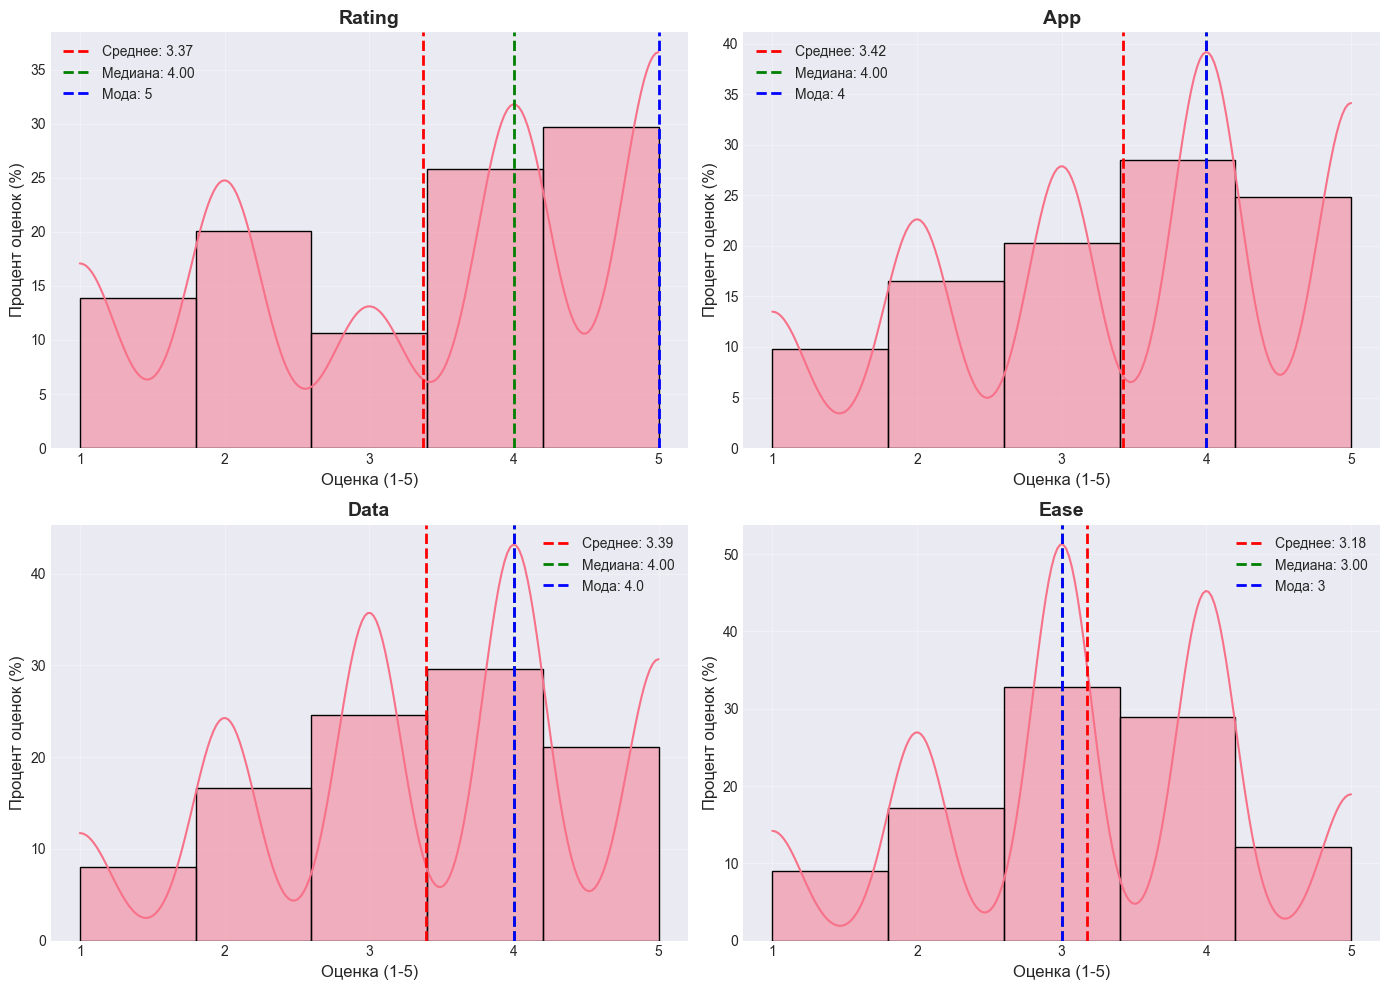


Средние значения рейтингов:
- Rating: 3.374 ± 1.435
- App: 3.421 ± 1.289
- Data: 3.390 ± 1.215
- Ease: 3.177 ± 1.129


In [5]:
# Визуализация распределений
rating_columns = ['Rating', 'App', 'Data', 'Ease']
plot_distributions(ratings_processed, rating_columns)

# Дополнительный анализ: средние значения
print("\nСредние значения рейтингов:")
for col in rating_columns:
    mean_val = ratings_processed[col].mean()
    std_val = ratings_processed[col].std()
    print(f"- {col}: {mean_val:.3f} ± {std_val:.3f}")

## 5. Корреляционный анализ

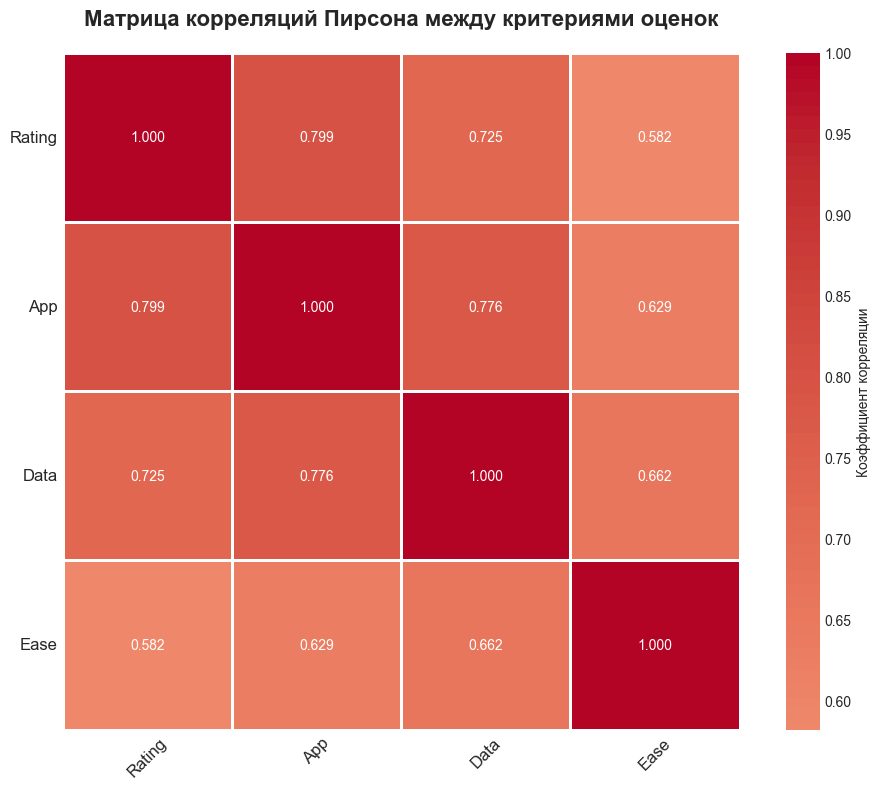


Статистическая значимость корреляций (p-value):
- Rating vs App: r = 0.7988, p = 0.0000e+00
- Rating vs Data: r = 0.7247, p = 0.0000e+00
- Rating vs Ease: r = 0.5821, p = 0.0000e+00

РЕГРЕССИОННЫЙ АНАЛИЗ ДЛЯ ПРЕДСКАЗАНИЯ ОБЩЕГО РЕЙТИНГА
Коэффициенты линейной регрессии (влияние на общий рейтинг):
- App: 0.6416
- Data: 0.2771
- Ease: 0.0824
- Intercept: -0.0221
- R² score: 0.6678


In [6]:
# Визуализация корреляций
plot_correlations(ratings_processed, rating_columns)

# Статистический анализ корреляций
print("\nСтатистическая значимость корреляций (p-value):")
for criterion in ['App', 'Data', 'Ease']:
    corr_coef, p_value = stats.pearsonr(ratings_processed['Rating'], ratings_processed[criterion])
    print(f"- Rating vs {criterion}: r = {corr_coef:.4f}, p = {p_value:.4e}")

# Регрессионный анализ
from sklearn.linear_model import LinearRegression

X = ratings_processed[['App', 'Data', 'Ease']]
y = ratings_processed['Rating']

model = LinearRegression()
model.fit(X, y)

print("\n" + "="*50)
print("РЕГРЕССИОННЫЙ АНАЛИЗ ДЛЯ ПРЕДСКАЗАНИЯ ОБЩЕГО РЕЙТИНГА")
print("="*50)
print("Коэффициенты линейной регрессии (влияние на общий рейтинг):")
for col, coef in zip(['App', 'Data', 'Ease'], model.coef_):
    print(f"- {col}: {coef:.4f}")
print(f"- Intercept: {model.intercept_:.4f}")
print(f"- R² score: {model.score(X, y):.4f}")

## 6. Влияние контекстных переменных

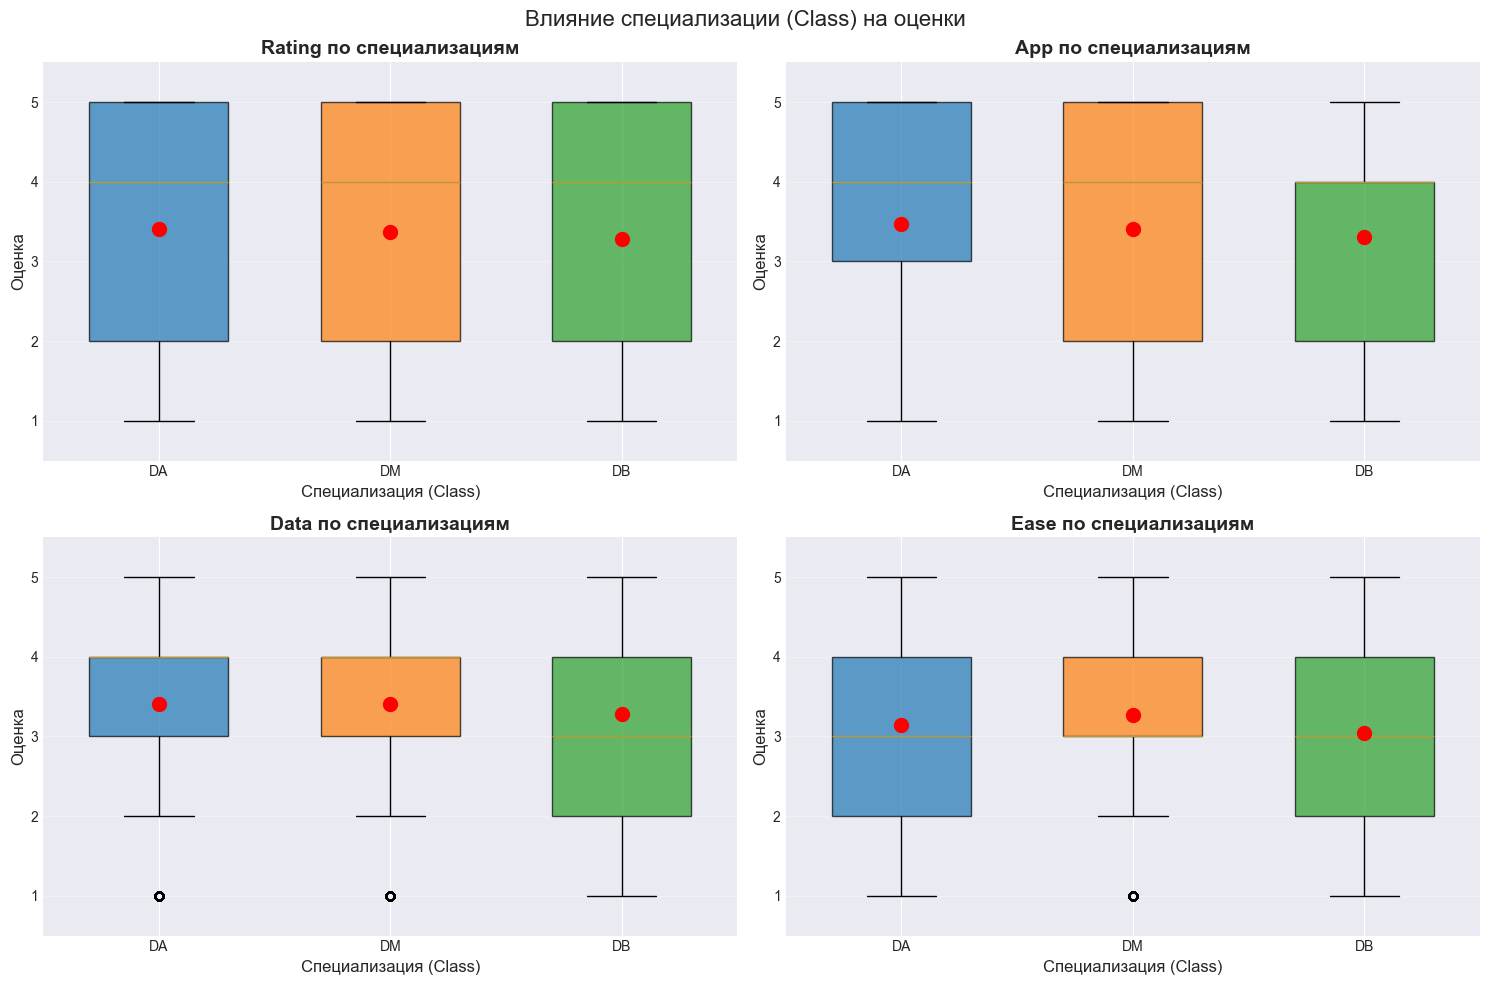


Статистический анализ различий между специализациями (ANOVA):
- Rating: F = 2.5039, p = 0.0819
- App: F = 5.1304, p = 0.0059
- Data: F = 3.9180, p = 0.0199
- Ease: F = 13.5423, p = 0.0000


In [7]:
# Анализ влияния специализации (Class)
class_order = ['DA', 'DM', 'DB']
class_palette = {'DA': '#1f77b4', 'DM': '#ff7f0e', 'DB': '#2ca02c'}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Влияние специализации (Class) на оценки', fontsize=16)

for idx, criterion in enumerate(['Rating', 'App', 'Data', 'Ease']):
    ax = axes[idx//2, idx%2]
    
    plot_data = []
    for cls in class_order:
        values = ratings_processed[ratings_processed['Class'] == cls][criterion].values
        plot_data.append(values)
    
    box = ax.boxplot(plot_data, patch_artist=True, labels=class_order, widths=0.6)
    
    for patch, cls in zip(box['boxes'], class_order):
        patch.set_facecolor(class_palette[cls])
        patch.set_alpha(0.7)
    
    ax.set_title(f'{criterion} по специализациям', fontsize=14, fontweight='bold')
    ax.set_xlabel('Специализация (Class)', fontsize=12)
    ax.set_ylabel('Оценка', fontsize=12)
    ax.set_ylim(0.5, 5.5)
    ax.grid(True, alpha=0.3, axis='y')
    
    for i, cls in enumerate(class_order):
        mean_val = ratings_processed[ratings_processed['Class'] == cls][criterion].mean()
        ax.scatter(i+1, mean_val, color='red', s=100, zorder=5, 
                  label='Среднее' if i == 0 else None)

plt.tight_layout()
plt.show()

# Статистический анализ различий между классами
print("\nСтатистический анализ различий между специализациями (ANOVA):")
for criterion in ['Rating', 'App', 'Data', 'Ease']:
    groups = [ratings_processed[ratings_processed['Class'] == cls][criterion] for cls in class_order]
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"- {criterion}: F = {f_stat:.4f}, p = {p_value:.4f}")


------------------------------
АНАЛИЗ ВЛИЯНИЯ СЕМЕСТРА (Semester)
------------------------------


Rating                 App   Data   Ease
           mean    std count   mean   mean   mean
Semester                                         
Fall      3.388  1.432  3417  3.444  3.398  3.214
Spring    3.347  1.441  1813  3.378  3.376  3.108

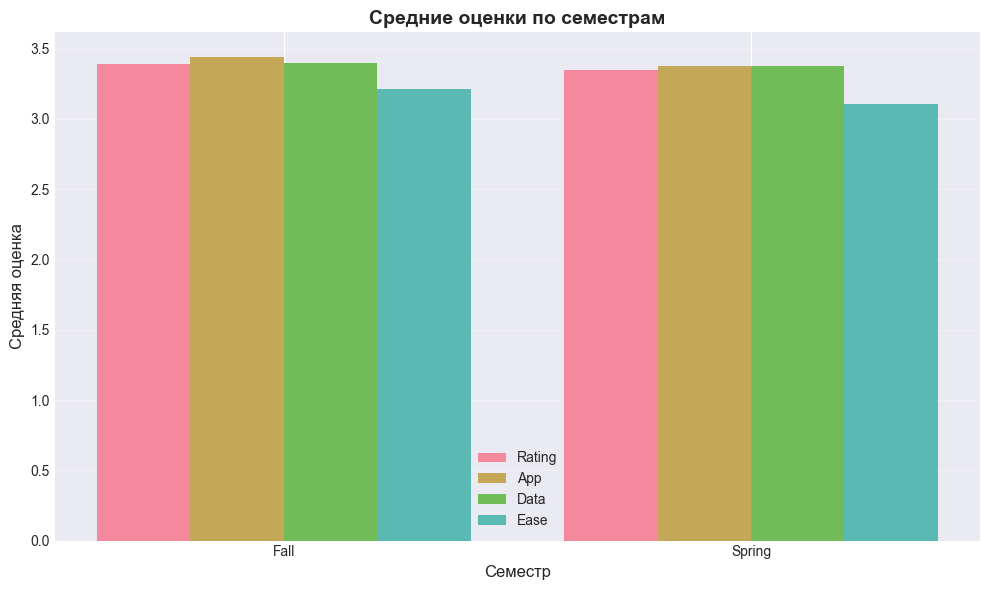

In [8]:
# Анализ влияния семестра
print("\n" + "-"*30)
print("АНАЛИЗ ВЛИЯНИЯ СЕМЕСТРА (Semester)")
print("-"*30)

semester_analysis = ratings_processed.groupby('Semester').agg({
    'Rating': ['mean', 'std', 'count'],
    'App': 'mean',
    'Data': 'mean', 
    'Ease': 'mean'
}).round(3)

display(semester_analysis)

# Визуализация
plt.figure(figsize=(10, 6))
semester_means = ratings_processed.groupby('Semester')[['Rating', 'App', 'Data', 'Ease']].mean()

x = np.arange(len(semester_means.index))
width = 0.2

for i, criterion in enumerate(['Rating', 'App', 'Data', 'Ease']):
    plt.bar(x + i*width - 0.3, semester_means[criterion], 
            width=width, label=criterion, alpha=0.8)

plt.xlabel('Семестр', fontsize=12)
plt.ylabel('Средняя оценка', fontsize=12)
plt.title('Средние оценки по семестрам', fontsize=14, fontweight='bold')
plt.xticks(x, semester_means.index)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


КОМБИНИРОВАННЫЙ АНАЛИЗ: Class × Semester
Средний общий рейтинг по комбинациям Class × Semester:


Semester,Fall,Spring
Class,,
DA,3.424,3.383
DB,3.247,3.402
DM,3.415,3.296



Количество оценок по комбинациям Class × Semester:


Semester,Fall,Spring
Class,,
DA,1713,823
DB,640,204
DM,1064,786


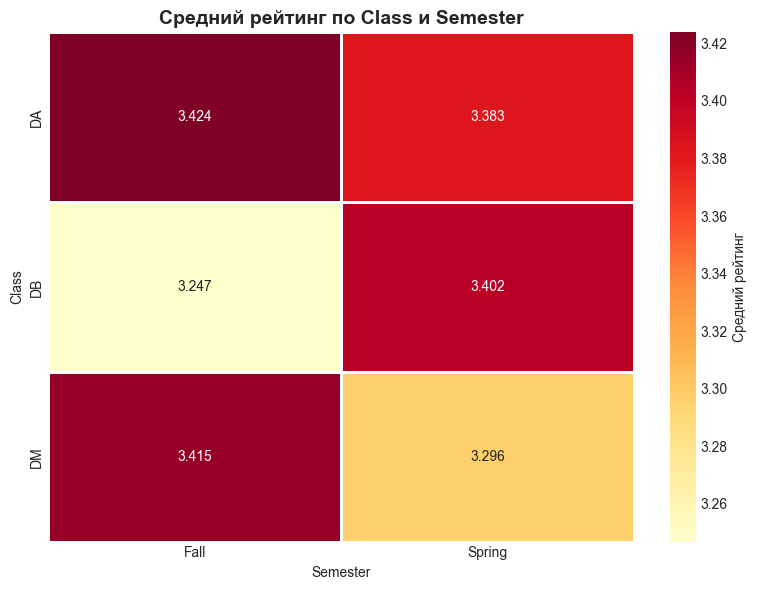

In [9]:
# Комбинированный анализ Class × Semester
print("\n" + "="*50)
print("КОМБИНИРОВАННЫЙ АНАЛИЗ: Class × Semester")
print("="*50)

pivot_table = ratings_processed.pivot_table(
    values='Rating',
    index='Class',
    columns='Semester',
    aggfunc=['mean', 'count']
).round(3)

print("Средний общий рейтинг по комбинациям Class × Semester:")
display(pivot_table['mean'])

print("\nКоличество оценок по комбинациям Class × Semester:")
display(pivot_table['count'])

# Heatmap
plt.figure(figsize=(8, 6))
heatmap_data = ratings_processed.pivot_table(
    values='Rating', 
    index='Class', 
    columns='Semester', 
    aggfunc='mean'
)

sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', 
            fmt='.3f', linewidths=1, cbar_kws={'label': 'Средний рейтинг'})

plt.title('Средний рейтинг по Class и Semester', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Сохранение обработанных данных

In [10]:
# Сохранение обработанных данных
import os
os.makedirs('../data/processed', exist_ok=True)

ratings_processed.to_csv('../data/processed/ratings_processed.csv', index=False)
users.to_csv('../data/processed/users_processed.csv', index=False)
items.to_csv('../data/processed/items_processed.csv', index=False)

print("Обработанные данные сохранены в data/processed/")
print(f"- ratings_processed.csv: {ratings_processed.shape}")
print(f"- users_processed.csv: {users.shape}")
print(f"- items_processed.csv: {items.shape}")

Обработанные данные сохранены в data/processed/
- ratings_processed.csv: (5230, 9)
- users_processed.csv: (476, 4)
- items_processed.csv: (70, 4)


## Выводы анализа

1. **О ДАТАСЕТЕ:**
   - 5,230 оценок от 476 пользователей по 70 темам проектов
   - Плотность данных: ~15.7% (выше средней для образовательных данных)
   - Многокритериальность: 4 оценки на каждый выбор (общая + 3 критерия)

2. **О РАСПРЕДЕЛЕНИИ РЕЙТИНГОВ:**
   - Все рейтинги скошены вправо (больше высоких оценок)
   - Критерий 'Ease' имеет наименьшее среднее (3.18) - студенты ценят сложные задачи
   - Наибольшая вариативность в 'App' (предпочтения по предметной области)

3. **О КОРРЕЛЯЦИЯХ:**
   - Все критерии сильно коррелируют с общим рейтингом (r > 0.58)
   - 'App' имеет максимальную корреляцию с общим рейтингом (r = 0.80)
   - Критерии между собой также коррелируют (0.63-0.78)

4. **О ВЛИЯНИИ КОНТЕКСТА:**
   - Специализация (Class) статистически значимо влияет на все оценки
   - Семестр (Semester) оказывает меньшее влияние
   - Комбинация Class × Semester показывает различия в строгости оценок

5. **ИМПЛИКАЦИИ ДЛЯ RL-МОДЕЛИ:**
   - **State:** Должен включать Class, Semester, историю предпочтений
   - **Reward функция:** Многокритериальная, с весами на основе корреляций
   - **Action space:** 70 тем, но можно кластеризовать по критериям
   - **Особенность:** Учесть систематические различия между специализациями